# **Travaux Pratiques Fusion et Multimodalité**

M2 SD/A2IA

Rodrigo César Coelho Fernandes

## Datasets

In [ ]:
# cd drive/MyDrive/RL

/content/drive/MyDrive/RL


In [2]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score

In [ ]:
data, meta = arff.loadarff("WDBC.arff.txt")
df = pd.DataFrame(data)

if df['Class'].dtype == object:
    df['Class'] = df['Class'].str.decode('utf-8').astype(int)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Features shape: (569, 30)
Labels shape: (569,)


In [4]:
data, meta = arff.loadarff("satimage.arff.txt")
df2 = pd.DataFrame(data)
df2.rename(columns={'class': 'Class'}, inplace=True)
# df['Class'] = df['Class'].astype(bytes)
df2['Class'] = (df2['Class'].replace(b'1.',1)
                          .replace(b'2.',2)
                          .replace(b'3.',3)
                          .replace(b'4.',4)
                          .replace(b'5.',5)
                          .replace(b'7.',6))

X2 = df2.iloc[:, :-1].values
y2 = df2.iloc[:, -1].values

print(f"Features shape: {X2.shape}")
print(f"Labels shape: {y2.shape}")


Features shape: (6430, 36)
Labels shape: (6430,)


/tmp/ipykernel_989/2139789912.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(b'7.',6))


In [5]:
def plot_bagging(n_estimators_list, tree_test_acc_acc_model, tree_test_acc_oob_model,
                 knn_test_acc_acc_model, knn_test_acc_oob_model):

    color_acc_tree = "tab:green"
    color_oob_tree = "tab:olive"
    color_acc_knn = "tab:blue"
    color_oob_knn = "tab:cyan"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

    # ---------- Decision Tree ----------
    ax1 = axes[0]
    ax1.set_title("Decision Tree Bagging")

    l1, = ax1.plot(n_estimators_list, tree_test_acc_acc_model, color=color_acc_tree,
                   marker='o', label="Test Acc (train)")
    l2, = ax1.plot(n_estimators_list, tree_test_acc_oob_model, color=color_oob_tree,
                   marker='s', linestyle='--', label="Test Acc (train+val / OOB)")

    ax1.set_xlabel("Number of classifiers")
    ax1.set_ylabel("Test Accuracy")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # ---------- kNN ----------
    ax2 = axes[1]
    ax2.set_title("kNN Bagging")

    l3, = ax2.plot(n_estimators_list, knn_test_acc_acc_model, color=color_acc_knn,
                   marker='o', label="Test Acc (train)")
    l4, = ax2.plot(n_estimators_list, knn_test_acc_oob_model, color=color_oob_knn,
                   marker='s', linestyle='--', label="Test Acc (train+val / OOB)")

    ax2.set_xlabel("Number of classifiers")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()


def simple_plot(x, y, color, xlabel="x", ylabel="y"):
    """
    Simple plot of y over x.
    """
    plt.figure()
    plt.plot(x, y, marker='o', color=color)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_double(x, y1, y2, color1, color2, xlabel="x", y1_label="y1", y2_label="y2"):
    """
    Simple plot of two lines (y1, y2) over x.
    """
    plt.figure()
    plt.plot(x, y1, marker='o', color=color1, label=y1_label)
    plt.plot(x, y2, marker='s', color=color2, label=y2_label)
    plt.xlabel(xlabel)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()




# =========================================

## **1- Bagging**

### Code

In [ ]:
class Bagging:
    def __init__(self, base_estimator="tree", n_estimators=10, knn_k=5, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.knn_k = knn_k
        self.random_state = random_state
        self.models = []
        self.oob_indices_ = []

    def _create_model(self, seed):
        if self.base_estimator == "tree":
            return DecisionTreeClassifier(max_depth=1, random_state=seed)
        elif self.base_estimator == "knn":
            return KNeighborsClassifier(
                n_neighbors=self.knn_k,
                algorithm="brute",
                n_jobs=1
            )

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)

        self.models = []
        self.oob_indices_ = []
        n_samples = X.shape[0]

        for i in range(self.n_estimators):
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]

            # Store OOB indices
            oob_indices = np.setdiff1d(np.arange(n_samples), np.unique(indices))

            model = self._create_model(seed=i)
            model.fit(X_boot, y_boot)
            self.models.append(model)
            self.oob_indices_.append(oob_indices)

    def predict(self, X):
        predictions = np.array([model.predict(X) for model in self.models])
        return np.apply_along_axis(
            lambda x: np.bincount(x).argmax(),
            axis=0,
            arr=predictions
        )

    def OutOfBagError(self, X, y):
        n_samples = X.shape[0]
        oob_predictions = [[] for _ in range(n_samples)]

        # get pred for its OOB samples
        for i in range(self.n_estimators):
            model = self.models[i]
            oob_idx = self.oob_indices_[i]

            if len(oob_idx) > 0:
                X_oob = X[oob_idx]
                preds = model.predict(X_oob)

                # Store pred
                for idx, pred in zip(oob_idx, preds):
                    oob_predictions[idx].append(pred)

        # majority vote
        y_pred_oob = np.zeros(n_samples, dtype=int)
        votes_available = np.zeros(n_samples, dtype=bool)

        for i in range(n_samples):
            if len(oob_predictions[i]) > 0:
                y_pred_oob[i] = np.bincount(oob_predictions[i]).argmax()
                votes_available[i] = True

        # Calc error 
        mask = votes_available
        if np.sum(mask) == 0:
            return 0  # No OOB samples

        return 1 - accuracy_score(y[mask], y_pred_oob[mask])


In [ ]:
def cv_optimal_n_estimators(X, y, base_estimator, n_estimators_list, max_depth=1, knn_k=5):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    mean_accuracies = []
    mean_oob_errors = []
    std_accuracies = []
    std_oob_errors = []
    mean_test_acc_model_acc = []
    mean_test_acc_model_oob = []

    for n_estimators in n_estimators_list:
        fold_accuracies = []
        fold_oob = []
        fold_test_acc_model_acc = []
        fold_test_acc_model_oob = []

        for trainval_idx, test_idx in skf.split(X, y):
            X_trainval, X_test = X[trainval_idx], X[test_idx]
            y_trainval, y_test = y[trainval_idx], y[test_idx]

            X_train, X_val, y_train, y_val = train_test_split(
                X_trainval, y_trainval,
                test_size=0.25,
                stratify=y_trainval,
                random_state=42
            )

            # -------- Model 1: Train on train, validate on val (ACC) --------
            model_acc = Bagging(
                base_estimator=base_estimator,
                n_estimators=n_estimators,
                knn_k=knn_k,
                random_state=42
            )

            model_acc.fit(X_train, y_train)

            y_val_pred = model_acc.predict(X_val)
            acc = accuracy_score(y_val, y_val_pred)
            fold_accuracies.append(acc)

            y_test_pred_acc = model_acc.predict(X_test)
            fold_test_acc_model_acc.append(accuracy_score(y_test, y_test_pred_acc))

            # -------- Model 2: Train on train+val, compute OOB --------
            model_oob = Bagging(
                base_estimator=base_estimator,
                n_estimators=n_estimators,
                knn_k=knn_k,
                random_state=42
            )

            model_oob.fit(X_trainval, y_trainval)

            oob = model_oob.OutOfBagError(X_trainval, y_trainval)
            fold_oob.append(oob)

            y_test_pred_oob = model_oob.predict(X_test)
            fold_test_acc_model_oob.append(accuracy_score(y_test, y_test_pred_oob))

        mean_accuracies.append(np.mean(fold_accuracies))
        mean_oob_errors.append(np.mean(fold_oob))
        std_accuracies.append(np.std(fold_accuracies))
        std_oob_errors.append(np.std(fold_oob))
        mean_test_acc_model_acc.append(np.mean(fold_test_acc_model_acc))
        mean_test_acc_model_oob.append(np.mean(fold_test_acc_model_oob))

    best_index_acc = np.argmax(mean_accuracies)
    best_index_oob = np.argmin(mean_oob_errors)

    return (
        n_estimators_list[best_index_acc], mean_accuracies,
        n_estimators_list[best_index_oob], mean_oob_errors,
        std_accuracies, std_oob_errors,
        mean_test_acc_model_acc, mean_test_acc_model_oob
    )

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The OOB error allows us to use our dataset more efficiently, as it gives us a prediction of the model's efficiency without needing to separate a portion of the dataset for validation. With this in mind, I will evaluate the efficiency of using OOB compared to a classic dataset split.
  </p>
  <p>
    The dataset was then divided into training, validation, and test sets to define the optimal number of classifiers. Two models were trained using a decision tree: the first trained with the test data, and we will select the best one based on its accuracy in validation. The second was trained with both training and validation data, and the optimal number of classifiers was defined by the OOB error. The same was done for kNN.
  </p>
</div>



### WDBC

In [ ]:
# nb classifiers
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200]

# ----- Decision Tree -----
(best_n_tree, tree_scores,
 best_n_tree2, tree_scores2,
 std_accuracies, std_oob_errors,
 tree_test_acc_acc_model, tree_test_acc_oob_model) = cv_optimal_n_estimators(
    X, y,
    base_estimator="tree",
    n_estimators_list=n_estimators_list,
    max_depth=1
)

print("Decision Tree Bagging")
for n, test_acc1, test_acc2, oob, stdoob in zip(
        n_estimators_list,
        tree_test_acc_acc_model,
        tree_test_acc_oob_model,
        tree_scores2,
        std_oob_errors):

    print(f"n_estimators={n:3d} | Test acc (train): {test_acc1:.4f} | Test acc (train+val/OOB): {test_acc2:.4f} | OOB error={oob:.4f}±{stdoob:.4f}")

best_acc_test = tree_test_acc_acc_model[n_estimators_list.index(best_n_tree)]
best_oob_test = tree_test_acc_oob_model[n_estimators_list.index(best_n_tree2)]

print(f"Optimal nb classifiers (Acc): {best_n_tree} (test_acc={best_acc_test:.4f})")
print(f"Optimal nb classifiers (OOB): {best_n_tree2} (test_acc={best_oob_test:.4f})")
print()


# ----- kNN -----
(best_n_knn, knn_scores,
 best_n_knn2, knn_scores2,
 std_accuracies, std_oob_errors,
 knn_test_acc_acc_model, knn_test_acc_oob_model) = cv_optimal_n_estimators(
    X, y,
    base_estimator="knn",
    n_estimators_list=n_estimators_list,
    knn_k=5
)

print("kNN Bagging")
for n, test_acc1, test_acc2, oob, stdoob in zip(
        n_estimators_list,
        knn_test_acc_acc_model,
        knn_test_acc_oob_model,
        knn_scores2,
        std_oob_errors):

    print(f"n_estimators={n:3d} | Test acc (train): {test_acc1:.4f} | Test acc (train+val/OOB): {test_acc2:.4f} | OOB error={oob:.4f}±{stdoob:.4f}")

best_acc_test = knn_test_acc_acc_model[n_estimators_list.index(best_n_knn)]
best_oob_test = knn_test_acc_oob_model[n_estimators_list.index(best_n_knn2)]

print(f"Optimal nb classifiers (Acc): {best_n_knn} (test_acc={best_acc_test:.4f})")
print(f"Optimal nb classifiers (OOB): {best_n_knn2} (test_acc={best_oob_test:.4f})")

Decision Tree Bagging
n_estimators=  1 | Test acc (train): 0.8964 | Test acc (train+val/OOB): 0.9016 | OOB error=0.0942±0.0202
n_estimators=  5 | Test acc (train): 0.9175 | Test acc (train+val/OOB): 0.9069 | OOB error=0.0971±0.0042
n_estimators= 10 | Test acc (train): 0.9051 | Test acc (train+val/OOB): 0.9051 | OOB error=0.0920±0.0086
n_estimators= 20 | Test acc (train): 0.9034 | Test acc (train+val/OOB): 0.9086 | OOB error=0.0892±0.0097
n_estimators= 30 | Test acc (train): 0.9016 | Test acc (train+val/OOB): 0.9104 | OOB error=0.0861±0.0102
n_estimators= 50 | Test acc (train): 0.9069 | Test acc (train+val/OOB): 0.9157 | OOB error=0.0839±0.0081
n_estimators=100 | Test acc (train): 0.9087 | Test acc (train+val/OOB): 0.9227 | OOB error=0.0865±0.0098
n_estimators=150 | Test acc (train): 0.9104 | Test acc (train+val/OOB): 0.9192 | OOB error=0.0870±0.0141
n_estimators=200 | Test acc (train): 0.9087 | Test acc (train+val/OOB): 0.9175 | OOB error=0.0861±0.0148
Optimal nb classifiers (Acc): 200

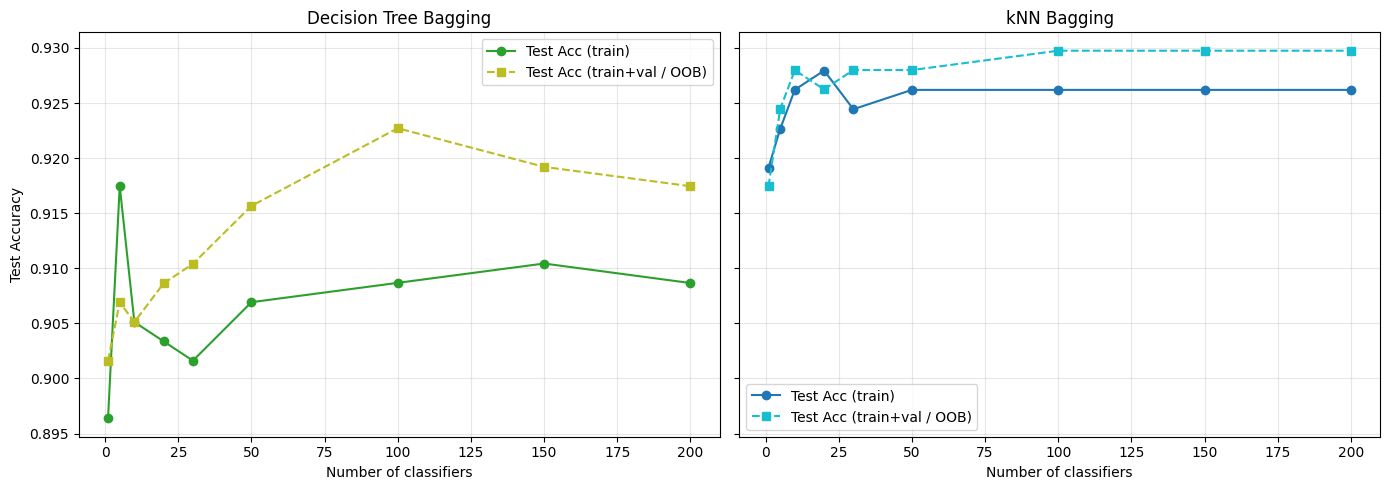

In [ ]:
plot_bagging(n_estimators_list, tree_test_acc_acc_model, tree_test_acc_oob_model, knn_test_acc_acc_model, knn_test_acc_oob_model)

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can see that the models selected based on accuracy and OOB error disagree on the ideal number of classifiers, which is not unexpected, since the OOB model was trained with a larger amount of data. For the decision tree architecture, the larger amount of training data was reflected in the test accuracy, as the OOB model obtained a slightly better result. For kNN, the test accuracy was practically the same, the models can be considered statistically equivalent.
  </p>
  <p>
    Analyzing the graph of test accuracy versus the number of classifiers, we see that the kNN models performed better than the DT models. The former appear to have a rapid growth trend followed by convergence. For DT, the trend is similar, but noisier.
  </p>
</div>

### Satimage

In [10]:
# nb classifiers
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200]

# ----- Decision Tree -----
(best_n_tree, tree_scores,
 best_n_tree2, tree_scores2,
 std_accuracies, std_oob_errors,
 tree_test_acc_acc_model, tree_test_acc_oob_model) = cv_optimal_n_estimators(
    X2, y2,
    base_estimator="tree",
    n_estimators_list=n_estimators_list,
    max_depth=1
)

print("Decision Tree Bagging")
for n, test_acc1, test_acc2, oob, stdoob in zip(
        n_estimators_list,
        tree_test_acc_acc_model,
        tree_test_acc_oob_model,
        tree_scores2,
        std_oob_errors):

    print(f"n_estimators={n:3d} | Test acc (train): {test_acc1:.4f} | Test acc (train+val/OOB): {test_acc2:.4f} | OOB error={oob:.4f}±{stdoob:.4f}")

best_acc_test = tree_test_acc_acc_model[n_estimators_list.index(best_n_tree)]
best_oob_test = tree_test_acc_oob_model[n_estimators_list.index(best_n_tree2)]

print(f"Optimal nb classifiers (Acc): {best_n_tree} (test_acc={best_acc_test:.4f})")
print(f"Optimal nb classifiers (OOB): {best_n_tree2} (test_acc={best_oob_test:.4f})")
print()


# ----- kNN -----
(best_n_knn, knn_scores,
 best_n_knn2, knn_scores2,
 std_accuracies, std_oob_errors,
 knn_test_acc_acc_model, knn_test_acc_oob_model) = cv_optimal_n_estimators(
    X2, y2,
    base_estimator="knn",
    n_estimators_list=n_estimators_list,
    knn_k=5
)

print("kNN Bagging")
for n, test_acc1, test_acc2, oob, stdoob in zip(
        n_estimators_list,
        knn_test_acc_acc_model,
        knn_test_acc_oob_model,
        knn_scores2,
        std_oob_errors):

    print(f"n_estimators={n:3d} | Test acc (train): {test_acc1:.4f} | Test acc (train+val/OOB): {test_acc2:.4f} | OOB error={oob:.4f}±{stdoob:.4f}")

best_acc_test = knn_test_acc_acc_model[n_estimators_list.index(best_n_knn)]
best_oob_test = knn_test_acc_oob_model[n_estimators_list.index(best_n_knn2)]

print(f"Optimal nb classifiers (Acc): {best_n_knn} (test_acc={best_acc_test:.4f})")
print(f"Optimal nb classifiers (OOB): {best_n_knn2} (test_acc={best_oob_test:.4f})")

Decision Tree Bagging
n_estimators=  1 | Test acc (train): 0.4286 | Test acc (train+val/OOB): 0.4275 | OOB error=0.5751±0.0057
n_estimators=  5 | Test acc (train): 0.4286 | Test acc (train+val/OOB): 0.4288 | OOB error=0.5745±0.0032
n_estimators= 10 | Test acc (train): 0.4300 | Test acc (train+val/OOB): 0.4300 | OOB error=0.5730±0.0050
n_estimators= 20 | Test acc (train): 0.4300 | Test acc (train+val/OOB): 0.4288 | OOB error=0.5729±0.0029
n_estimators= 30 | Test acc (train): 0.4300 | Test acc (train+val/OOB): 0.4286 | OOB error=0.5717±0.0022
n_estimators= 50 | Test acc (train): 0.4300 | Test acc (train+val/OOB): 0.4300 | OOB error=0.5712±0.0023
n_estimators=100 | Test acc (train): 0.4269 | Test acc (train+val/OOB): 0.4300 | OOB error=0.5712±0.0028
n_estimators=150 | Test acc (train): 0.4300 | Test acc (train+val/OOB): 0.4300 | OOB error=0.5713±0.0028
n_estimators=200 | Test acc (train): 0.4300 | Test acc (train+val/OOB): 0.4300 | OOB error=0.5710±0.0027
Optimal nb classifiers (Acc): 20 

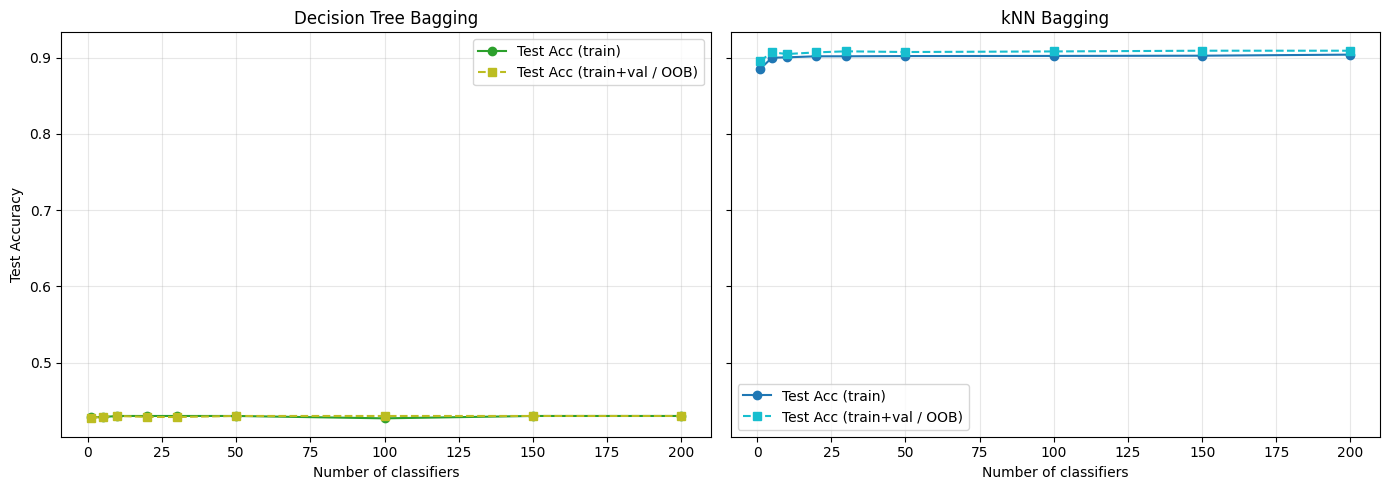

In [11]:
plot_bagging(n_estimators_list, tree_test_acc_acc_model, tree_test_acc_oob_model, knn_test_acc_acc_model, knn_test_acc_oob_model)

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    In this second, more complex dataset, we see that the DT models obtained unsatisfactory results, it is possible that DTs with such shallow depth are not strong enough to classify the data well.
  </p>
</div>

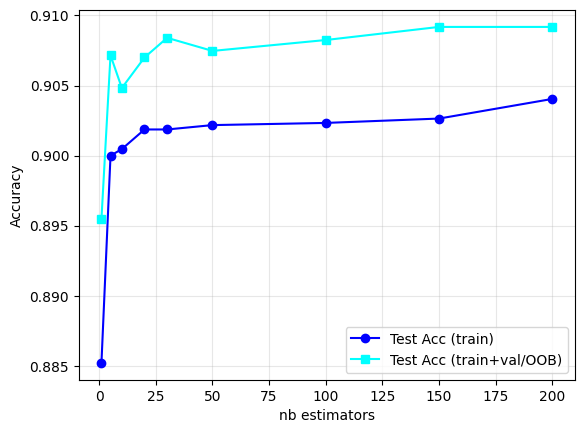

In [12]:
plot_double(n_estimators_list, knn_test_acc_acc_model, knn_test_acc_oob_model, "blue", "cyan", "nb estimators", "Test Acc (train)", "Test Acc (train+val/OOB)")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    With a closer focus on the kNN models, we see that once again they maintained the trend of rapid accuracy growth with the increase in the number of classifiers until a point of convergence. However, this time the convergence is less evident. The greater complexity of the dataset introduced some noise into the model's performance. The model validated with the OOB error achieved higher accuracy because it used more training data and thus could generalize better in test.
  </p>
  <p>
    It is also worth noting that the training time is quite long for the kNN model, but this is compensated for by its good results.
  </p>
</div>



# =========================================

## **2- Boosting**

### Code

In [ ]:
class AdaBoost:
    def __init__(self, base_estimator="tree", n_estimators=50, max_depth=1, knn_k=5):
        self.n_estimators = n_estimators
        self.alphas = []
        self.models = []
        self.base_estimator=base_estimator
        self.max_depth=max_depth
        self.knn_k=knn_k

    def _create_model(self, seed):
        if self.base_estimator == "tree":
            return DecisionTreeClassifier(max_depth=self.max_depth, random_state=seed)
        elif self.base_estimator == "knn":
            return KNeighborsClassifier(
                        n_neighbors=self.knn_k,
                        algorithm="brute",
                        n_jobs=1
                    )

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.classes_ = np.unique(y)

        self.class_map_ = {self.classes_[0]: -1, self.classes_[1]: 1}
        y_transformed = np.array([self.class_map_[label] for label in y])

        w = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            # print(w[:9])
            # model = DecisionTreeClassifier(max_depth=1)
            model = self._create_model(seed=42)
            model.fit(X, y, sample_weight=w)
            predictions = model.predict(X)

            pred_transformed = np.array([self.class_map_[p] for p in predictions])
            incorrect = (pred_transformed != y_transformed)
            err = np.sum(w * incorrect) / np.sum(w)
            err = np.clip(err, 1e-10, 1 - 1e-10)

            alpha = 0.5 * np.log((1 - err) / err)

            self.models.append(model)
            self.alphas.append(alpha)

            w *= np.exp(-alpha * y_transformed * pred_transformed)
            w /= np.sum(w)

    def predict(self, X):
        strong_preds = np.zeros(X.shape[0])

        for model, alpha in zip(self.models, self.alphas):
            predictions = model.predict(X)
            pred_transformed = np.array([self.class_map_[p] for p in predictions])
            strong_preds += alpha * pred_transformed

        pred_labels = np.where(strong_preds >= 0,
                               self.classes_[1],
                               self.classes_[0])
        return pred_labels



### WDBC

In [17]:
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200, 250, 300, 350, 400, 500]
# n_estimators_list = [1,5]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # ----- Decision Tree -----
accs = []

for n in n_estimators_list:
  adaboost = AdaBoost(n_estimators=n, base_estimator="tree", max_depth=1)
  adaboost.fit(X_train, y_train)

  predictions = adaboost.predict(X_test)
  acc = accuracy_score(y_test, predictions)
  print(f"n_estimators = {n:2d} | Accuracy = {acc:.4f}")

  accs = np.append(accs, acc)

best_index = np.argmax(accs)
print(f"Optimal nb classifiers (Acc): {n_estimators_list[best_index]}")


n_estimators =  1 | Accuracy = 0.8947
n_estimators =  5 | Accuracy = 0.9766
n_estimators = 10 | Accuracy = 0.9766
n_estimators = 20 | Accuracy = 0.9591
n_estimators = 30 | Accuracy = 0.9649
n_estimators = 50 | Accuracy = 0.9708
n_estimators = 100 | Accuracy = 0.9708
n_estimators = 150 | Accuracy = 0.9766
n_estimators = 200 | Accuracy = 0.9825
n_estimators = 250 | Accuracy = 0.9708
n_estimators = 300 | Accuracy = 0.9766
n_estimators = 350 | Accuracy = 0.9883
n_estimators = 400 | Accuracy = 0.9883
n_estimators = 500 | Accuracy = 0.9883
Optimal nb classifiers (Acc): 350


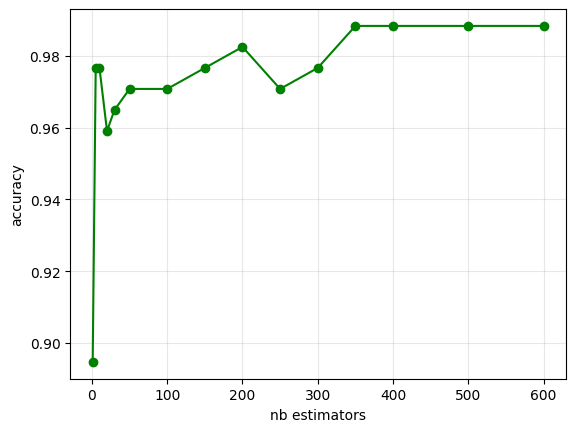

In [16]:
simple_plot(n_estimators_list, accs, "green", "nb estimators", "accuracy")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The Adaboost algorithm achieved significantly better results than those previously seen with Bagging models. This may be related to the fact that Adaboost continuously and actively improves its classifiers, while Bagging uses classifiers with equal weights for its classification.
  </p>
  <p>
    This continuous improvement of the classifiers also resulted in a more evident upward curve than previously observed, requiring an increase in the number of classifiers analyzed to see convergence being achieved.
  </p>
  <p>
    The Adaboost model was only used on the first dataset, as it is not adapted for datasets with more than one class.
  </p>
</div>

# =========================================

## **3- Random Subspace Method**

### Code

In [18]:
class RandomSubspace:
    def __init__(self, base_estimator="tree", n_estimators=10, max_features="sqrt",max_depth=1, knn_k=5, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.knn_k = knn_k
        self.random_state = random_state
        self.models = []
        self.feature_indices_ = []

    def _create_model(self, seed):
        if self.base_estimator == "tree":
            return DecisionTreeClassifier(max_depth=self.max_depth, random_state=seed)
        elif self.base_estimator == "knn":
            return KNeighborsClassifier(
                n_neighbors=self.knn_k,
                algorithm="brute",
                n_jobs=1
            )

    def _num_features(self, n_features):
        if self.max_features == "sqrt":
            return int(np.sqrt(n_features))
        elif self.max_features == "log2":
            return int(np.log2(n_features))
        elif isinstance(self.max_features, float):
            return int(self.max_features * n_features)
        else:
            return int(self.max_features)

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.models = []
        self.feature_indices_ = []

        n_samples, n_features = X.shape
        n_sub_features = self._num_features(n_features)

        for i in range(self.n_estimators):
            feat_idx = np.random.choice(
                n_features,
                n_sub_features,
                replace=False
            )

            model = self._create_model(seed=i)
            model.fit(X[:, feat_idx], y)

            self.models.append(model)
            self.feature_indices_.append(feat_idx)

    def predict(self, X):
        predictions = []

        for model, feat_idx in zip(self.models, self.feature_indices_):
            preds = model.predict(X[:, feat_idx])
            predictions.append(preds)

        predictions = np.array(predictions)

        return np.apply_along_axis(
            lambda x: np.bincount(x).argmax(),
            axis=0,
            arr=predictions
        )


In [19]:
def cv_optimal_n_estimators_rsm(
    X,
    y,
    base_estimator,
    n_estimators_list,
    max_features="sqrt",
    knn_k=5,
    max_depth=1
):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    mean_accuracies = []
    std_accuracies = []

    for n_estimators in n_estimators_list:
        fold_accuracies = []

        for train_idx, val_idx in skf.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = RandomSubspace(
                base_estimator=base_estimator,
                n_estimators=n_estimators,
                max_features=max_features,
                knn_k=knn_k,
                random_state=42
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            fold_accuracies.append(accuracy_score(y_val, y_pred))

        mean_accuracies.append(np.mean(fold_accuracies))
        std_accuracies.append(np.std(fold_accuracies))


    best_index = np.argmax(mean_accuracies)
    return n_estimators_list[best_index], mean_accuracies,std_accuracies


### WDBC

In [20]:
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200]

# ----- Decision Tree -----
best_n_tree, tree_scores, stdacc = cv_optimal_n_estimators_rsm(
    X, y,
    base_estimator="tree",
    n_estimators_list=n_estimators_list,
    max_features="sqrt",
    max_depth=1
)

print("Decision Tree – Random Subspace")
for n, acc, std in zip(n_estimators_list, tree_scores, stdacc):
    print(f"n_estimators={n:3d} | CV accuracy={acc:.4f} ± {std:.4f}")

print(f"Optimal nb classifiers: {best_n_tree}")
print()

# ----- kNN -----
best_n_knn, knn_scores, stdacc = cv_optimal_n_estimators_rsm(
    X, y,
    base_estimator="knn",
    n_estimators_list=n_estimators_list,
    max_features="sqrt",
    knn_k=5
)

print("kNN – Random Subspace")
for n, acc, std in zip(n_estimators_list, knn_scores, stdacc):
    print(f"n_estimators={n:3d} | CV accuracy={acc:.4f} ± {std:.4f}")

print(f"Optimal nb classifiers: {best_n_knn}")


Decision Tree – Random Subspace
n_estimators=  1 | CV accuracy=0.9068 ± 0.0181
n_estimators=  5 | CV accuracy=0.8928 ± 0.0210
n_estimators= 10 | CV accuracy=0.9139 ± 0.0170
n_estimators= 20 | CV accuracy=0.9209 ± 0.0298
n_estimators= 30 | CV accuracy=0.9174 ± 0.0302
n_estimators= 50 | CV accuracy=0.9227 ± 0.0325
n_estimators=100 | CV accuracy=0.9192 ± 0.0279
n_estimators=150 | CV accuracy=0.9139 ± 0.0262
n_estimators=200 | CV accuracy=0.9174 ± 0.0286
Optimal nb classifiers: 50

kNN – Random Subspace
n_estimators=  1 | CV accuracy=0.9087 ± 0.0210
n_estimators=  5 | CV accuracy=0.8999 ± 0.0296
n_estimators= 10 | CV accuracy=0.8998 ± 0.0204
n_estimators= 20 | CV accuracy=0.9209 ± 0.0156
n_estimators= 30 | CV accuracy=0.9209 ± 0.0214
n_estimators= 50 | CV accuracy=0.9262 ± 0.0196
n_estimators=100 | CV accuracy=0.9420 ± 0.0233
n_estimators=150 | CV accuracy=0.9420 ± 0.0233
n_estimators=200 | CV accuracy=0.9420 ± 0.0233
Optimal nb classifiers: 100


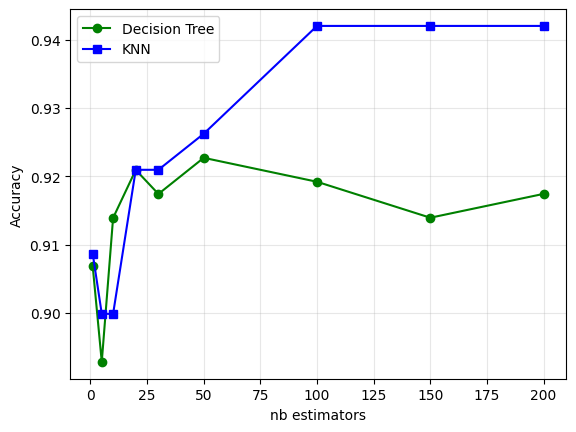

In [21]:
plot_double(n_estimators_list, tree_scores, knn_scores, "green", "blue", "nb estimators", "Decision Tree", "KNN")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The two trained RSM models achieved better results than Bagging, but lower than Adaboost. Once again, the kNN model proved superior to the DT model, which may indicate that the former is better adapted for classification in this dataset. The increasing trend in accuracy is also very present here, but convergence is achieved faster than in Adaboost.
  </p>
</div>

### Satimage

In [22]:
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200]

# ----- Decision Tree -----
best_n_tree, tree_scores, stdacc = cv_optimal_n_estimators_rsm(
    X2, y2,
    base_estimator="tree",
    n_estimators_list=n_estimators_list,
    max_features="sqrt",
    max_depth=1
)

print("Decision Tree – Random Subspace")
for n, acc, std in zip(n_estimators_list, tree_scores, stdacc):
    print(f"n_estimators={n:3d} | CV accuracy={acc:.4f} ± {std:.4f}")

print(f"Optimal nb classifiers: {best_n_tree}")
print()

# ----- kNN -----
best_n_knn, knn_scores, stdacc = cv_optimal_n_estimators_rsm(
    X2, y2,
    base_estimator="knn",
    n_estimators_list=n_estimators_list,
    max_features="sqrt",
    knn_k=5
)

print("kNN – Random Subspace")
for n, acc, std in zip(n_estimators_list, knn_scores, stdacc):
    print(f"n_estimators={n:3d} | CV accuracy={acc:.4f} ± {std:.4f}")

print(f"Optimal nb classifiers: {best_n_knn}")


Decision Tree – Random Subspace
n_estimators=  1 | CV accuracy=0.4269 ± 0.0039
n_estimators=  5 | CV accuracy=0.4272 ± 0.0041
n_estimators= 10 | CV accuracy=0.4170 ± 0.0040
n_estimators= 20 | CV accuracy=0.4278 ± 0.0036
n_estimators= 30 | CV accuracy=0.4244 ± 0.0054
n_estimators= 50 | CV accuracy=0.4272 ± 0.0044
n_estimators=100 | CV accuracy=0.4258 ± 0.0042
n_estimators=150 | CV accuracy=0.4267 ± 0.0042
n_estimators=200 | CV accuracy=0.4289 ± 0.0034
Optimal nb classifiers: 200

kNN – Random Subspace
n_estimators=  1 | CV accuracy=0.8454 ± 0.0071
n_estimators=  5 | CV accuracy=0.8854 ± 0.0061
n_estimators= 10 | CV accuracy=0.8908 ± 0.0047
n_estimators= 20 | CV accuracy=0.8972 ± 0.0062
n_estimators= 30 | CV accuracy=0.8963 ± 0.0062
n_estimators= 50 | CV accuracy=0.8977 ± 0.0071
n_estimators=100 | CV accuracy=0.8988 ± 0.0061
n_estimators=150 | CV accuracy=0.8988 ± 0.0066
n_estimators=200 | CV accuracy=0.8992 ± 0.0073
Optimal nb classifiers: 200


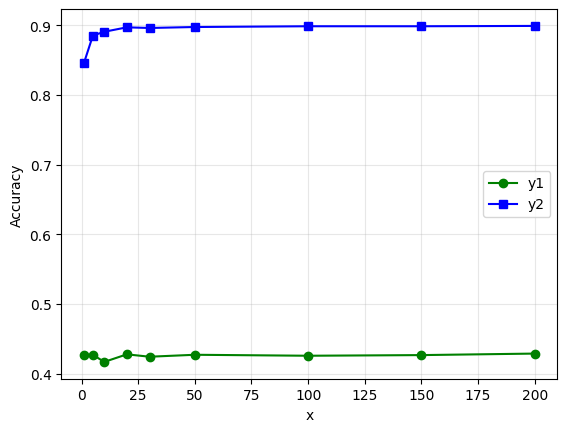

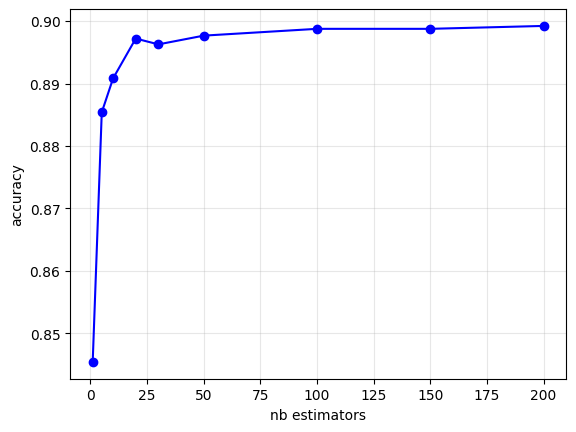

In [23]:
plot_double(n_estimators_list, tree_scores, knn_scores, "green", "blue")
simple_plot(n_estimators_list, knn_scores, "blue", "nb estimators", "accuracy")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    In this more complex dataset, the same Bagging phenomenon was observed, that is, the DT model was not able to generalize well the data, but the kNN model did, achieving the maximum accuracy that it is capable of delivering in just a few number of classifiers.
  </p>
  <p>
    It is interesting to note that for this dataset, the RSM model was less efficient than Bagging, while for the previous dataset the result is the opposite. This shows that one algorithm is not necessarily better than another, but rather that the right algorithm must be carefully chosen to address a problem.
  </p>
</div>

# =========================================

## **4- ECOC**

### Code

In [ ]:
def exhaustive_code_matrix(classes):
    K = len(classes)
    codes = []

    # Generate all binary vectors of length K
    for bits in itertools.product([0, 1], repeat=K):
        if sum(bits) == 0 or sum(bits) == K:
            continue  # trivial partitions
        if bits[0] == 0:
            continue  # avoid complements
        codes.append(bits)

    return np.array(codes).T  # shape (K, L)


In [7]:
class ECOC:
    def __init__(self, random_state=None, base_estimator="tree", max_depth=1, knn_k=5, n_estimators=200):
        self.random_state = random_state
        self.models = []
        self.code_matrix_ = None
        self.classes_ = None
        self.base_estimator = base_estimator
        self.max_depth = max_depth
        self.knn_k = knn_k
        self.n_estimators=n_estimators

    def _create_model(self, seed):
        if self.base_estimator == "tree":
            return DecisionTreeClassifier(max_depth=self.max_depth, random_state=seed)
        elif self.base_estimator == "knn":
            return KNeighborsClassifier(
                n_neighbors=self.knn_k,
                algorithm="brute",
                n_jobs=1)
        elif self.base_estimator == "adaboost":
                return AdaBoost(n_estimators=self.n_estimators, base_estimator="tree", max_depth=1)


    def fit(self, X, y):
        self.classes_ = np.unique(y)
        K = len(self.classes_)

        # Build exhaustive code matrix
        self.code_matrix_ = exhaustive_code_matrix(self.classes_)
        L = self.code_matrix_.shape[1]

        self.models = []

        for j in range(L):
            column = self.code_matrix_[:, j]

            # Map multiclass labels to binary labels for this classifier
            y_binary = np.array([
                column[np.where(self.classes_ == label)[0][0]]
                for label in y
            ])

            # clf = DecisionTreeClassifier(
            #     max_depth=1,
            #     random_state=None if self.random_state is None else self.random_state + j
            # )
            model = self._create_model(seed=self.random_state)
            model.fit(X, y_binary)
            self.models.append(model)

    def predict(self, X):
        # Collect predictions from all binary classifiers
        binary_predictions = np.array([
            model.predict(X) for model in self.models
        ]).T  # shape (n_samples, L)

        predictions = []

        for sample_code in binary_predictions:
            # Hamming distance to each class codeword
            distances = np.sum(
                sample_code != self.code_matrix_,
                axis=1
            )
            predictions.append(self.classes_[np.argmin(distances)])

        return np.array(predictions)


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    For ECOC, I decided to perform an additional analysis.
  </p>
  <p>
    The model with the best performance on the WDBC dataset was Adaboost, but it cannot be used directly for the Satimage dataset because this is a problem with more than two classes.
  </p>
  <p>
    However, since the ECOC algorithm transforms a problem with many classes into several problems with only two classes, the application of Adaboost becomes possible, that is, it is possible to create an ensemble of ensembles of classifiers.
  </p>
</div>

### Satimage

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.3, random_state=42)


# ----- Decision Tree -----
model = ECOC(random_state=42, base_estimator="tree", max_depth=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Tree – accuracy:", acc)


# ----- kNN -----
model = ECOC(random_state=42, base_estimator="knn", knn_k=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("kNN – accuracy:", acc)


# ----- Adaboost -----
model = ECOC(random_state=42, base_estimator="adaboost", n_estimators=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Adaboost – accuracy:", acc)


Tree – accuracy: 0.7558320373250389
kNN – accuracy: 0.9051321928460342
Adaboost – accuracy: 0.8833592534992224


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    In this simple test of the 3 types of classifiers, we see that the result obtained by DT was better compared to the previous algorithms, but still inferior to kNN. ECOC with Adaboost as a classifier obtained better accuracy than simple DT, which is expected since an Adaboost of DTs is certainly a better classifier than a simple DT. The result of the ECOC model with kNNs was slightly lower than the Bagging of kNNs, but they may still be statistically equivalent.
  </p>
  <p>
    Throughout all previous model analyses, fixed hyperparameter values ​​were used for the classifiers, only changing their quantity. Since in the case of ECOC the number of classifiers depends only on the number of classes, it may be interesting to analyze the HPs of the classifiers that make up the ensemble.
  </p>
</div>



### ECOC + DT

In [ ]:
max_depth_values = [1, 2, 3, 4, 5, 7, 10, None]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tree_scores = {}

for depth in max_depth_values:
    fold_accuracies = []

    for train_idx, val_idx in cv.split(X2, y2):
        X_train, X_val = X2[train_idx], X2[val_idx]
        y_train, y_val = y2[train_idx], y2[val_idx]

        model = ECOC(
            random_state=42,
            base_estimator="tree",
            max_depth=depth
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        fold_accuracies.append(accuracy_score(y_val, y_pred))

    tree_scores[depth] = np.mean(fold_accuracies)

best_depth = max(tree_scores, key=tree_scores.get)

print("Decision Tree CV results:")
for d, acc in tree_scores.items():
    print(f"max_depth={d}: mean accuracy={acc:.4f}")

print("\nBest max_depth:", best_depth)


Decision Tree CV results:
max_depth=1: mean accuracy=0.7361
max_depth=2: mean accuracy=0.7961
max_depth=3: mean accuracy=0.8327
max_depth=4: mean accuracy=0.8551
max_depth=5: mean accuracy=0.8664
max_depth=7: mean accuracy=0.8832
max_depth=10: mean accuracy=0.8961
max_depth=None: mean accuracy=0.9050

Best max_depth: None


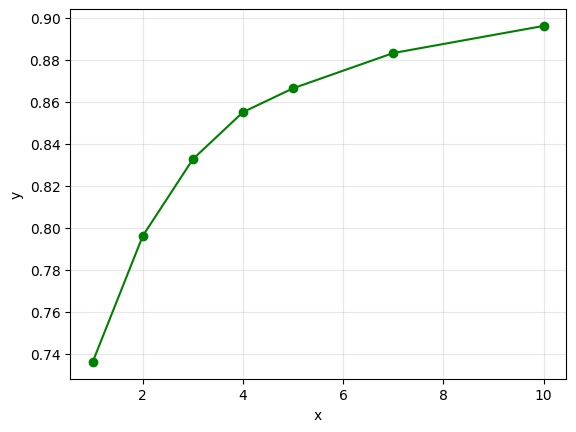

In [ ]:
simple_plot(max_depth_values, list(tree_scores.values()), "green")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    It is possible to observe that increasing the maximum depth of the DT considerably improves accuracy, with depth=none being the best possible case. For this complex dataset, the DT needs to be deep to achieve a good enough classification as the final result of the ensemble. Using trunks, as in previous models, is efficient in terms of execution time, but it was the possible reason for the poor results with DT as a classifier.
  </p>
</div>

### ECOC + kNN

In [ ]:
knn_k_values = [1, 2, 3, 4, 5, 7, 9]

knn_scores = {}

for k in knn_k_values:
    fold_accuracies = []

    for train_idx, val_idx in cv.split(X2, y2):
        X_train, X_val = X2[train_idx], X2[val_idx]
        y_train, y_val = y2[train_idx], y2[val_idx]

        model = ECOC(
            random_state=42,
            base_estimator="knn",
            knn_k=k
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        fold_accuracies.append(accuracy_score(y_val, y_pred))

    knn_scores[k] = np.mean(fold_accuracies)

best_k = max(knn_scores, key=knn_scores.get)

print("kNN CV results:")
for k, acc in knn_scores.items():
    print(f"knn_k={k}: mean accuracy={acc:.4f}")

print("\nBest knn_k:", best_k)


kNN CV results:
knn_k=1: mean accuracy=0.9054
knn_k=3: mean accuracy=0.9076
knn_k=5: mean accuracy=0.9053
knn_k=7: mean accuracy=0.9028
knn_k=9: mean accuracy=0.9017
knn_k=11: mean accuracy=0.8978
knn_k=15: mean accuracy=0.8950

Best knn_k: 3


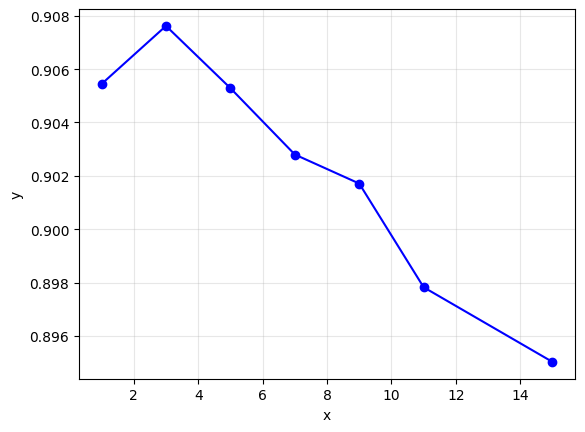

In [ ]:
simple_plot(knn_k_values, list(knn_scores.values()), "blue")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    In the case of kNN, we see that there is an optimal neighbor point, reaching almost the same level as the Bagging result for this dataset (0.9082).
  </p>
</div>

### ECOC + Adaboost

In [11]:
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200, 250, 300, 350, 400]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
adaboost_scores = {}

for n_estimators in n_estimators_list:
    fold_accuracies = []

    for train_idx, val_idx in skf.split(X2, y2):
        X_train, X_val = X2[train_idx], X2[val_idx]
        y_train, y_val = y2[train_idx], y2[val_idx]

        model = ECOC(
            random_state=42,
            base_estimator="adaboost",
            n_estimators=n_estimators
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        fold_accuracies.append(accuracy_score(y_val, y_pred))

    adaboost_scores[n_estimators] = np.mean(fold_accuracies)

best_n = max(adaboost_scores, key=adaboost_scores.get)

print("adaboost CV results:")
for n_estimators, acc in adaboost_scores.items():
    print(f"n_estimators={n_estimators}: mean accuracy={acc:.4f}")

print("\nBest n_estimators:", best_n)


adaboost CV results:
n_estimators=1: mean accuracy=0.7361
n_estimators=5: mean accuracy=0.8118
n_estimators=10: mean accuracy=0.8370
n_estimators=20: mean accuracy=0.8493
n_estimators=30: mean accuracy=0.8560
n_estimators=50: mean accuracy=0.8630
n_estimators=100: mean accuracy=0.8711
n_estimators=150: mean accuracy=0.8743
n_estimators=200: mean accuracy=0.8774
n_estimators=250: mean accuracy=0.8782
n_estimators=300: mean accuracy=0.8807
n_estimators=350: mean accuracy=0.8823
n_estimators=400: mean accuracy=0.8826

Best n_estimators: 400


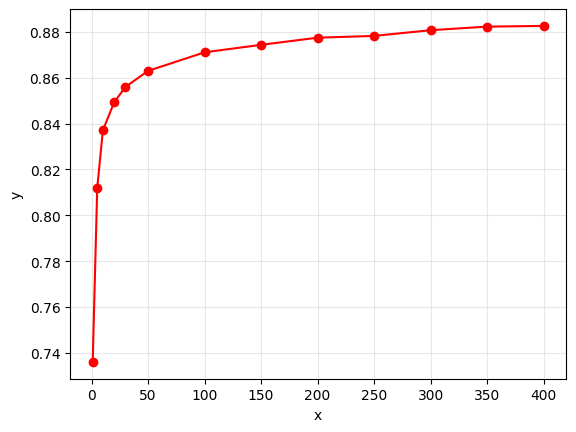

In [13]:
simple_plot(n_estimators_list, list(adaboost_scores.values()), "red")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We see that increasing the number of Adaboost classifiers improves ECOC performance. The curve does not appear to have reached convergence as it shows a slight upward trend, but the long execution time due to the complexity of the problem does not justify training with higher values.
  </p>
</div>

### Best models

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2
)

# Best Tree
tree_model = ECOC(
    random_state=42,
    base_estimator="tree",
    max_depth=best_depth
)
tree_model.fit(X_train, y_train)
tree_acc = accuracy_score(y_test, tree_model.predict(X_test))

# Best kNN
knn_model = ECOC(
    random_state=42,
    base_estimator="knn",
    knn_k=best_k
)
knn_model.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn_model.predict(X_test))

# Best adaboost
adaboost_model = ECOC(
    random_state=42,
    base_estimator="adaboost",
    n_estimators=best_n
)
adaboost_model.fit(X_train, y_train)
adaboost_acc = accuracy_score(y_test, adaboost_model.predict(X_test))

print("Final Tree accuracy:", tree_acc)
print("Final kNN accuracy:", knn_acc)
print("Final adaboost accuracy:", adaboost_acc)


Final Tree accuracy: 0.9082426127527217
Final kNN accuracy: 0.9020217729393468
Final adaboost accuracy: 0.8921721099015034


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The DT model without maximum depth obtained a better result than kNN, showing that DT can perform very well even in this complex dataset if it has ideal HP. We also see that training an ensemble of other ensembles proved less efficient than training an ensemble with simple and carefully selected classifiers. It is also worth mentioning that the execution time is a problem with this approach, as each of the Adaboost models requires a long of training time.
  </p>
</div>

# =========================================